# Day 060 — Gaussian Mixture Models (GMM)


In [8]:
# Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


## 1. Gaussian Mixture Models — Probabilistic Soft Clustering


In [9]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

X, y = make_blobs(n_samples=400, centers=3, cluster_std=1.0, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)
labels = gmm.predict(X_scaled)

print("Sample Soft Probabilities (first 5 samples):")
print(np.round(probs[:5], 3))

Sample Soft Probabilities (first 5 samples):
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


## 2. Expectation-Maximization (EM) Algorithm (E-step & M-step)


In [10]:
print(f"EM Converged: {gmm.converged_}")
print(f"Iterations to converge: {gmm.n_iter_}")
print(f"GMM Means:\n{gmm.means_}")
print(f"GMM Covariances Shape: {gmm.covariances_.shape}")

EM Converged: True
Iterations to converge: 2
GMM Means:
[[-0.19989363  1.1648994 ]
 [-1.08776577 -1.25197165]
 [ 1.28916236  0.07831361]]
GMM Covariances Shape: (3, 2, 2)


## 3. Soft Clustering Probabilities


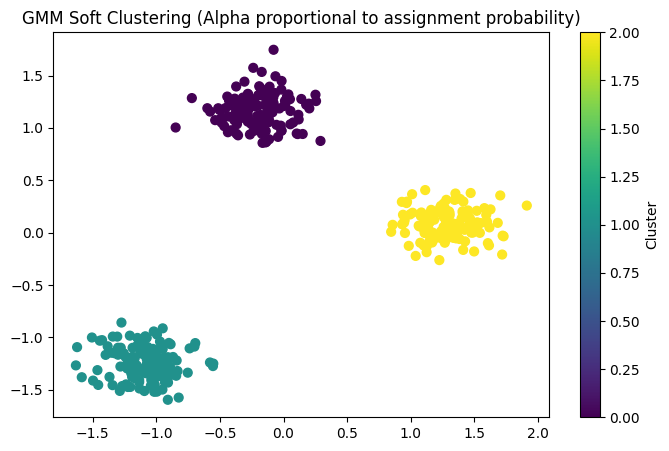

In [11]:
plt.figure(figsize=(8, 5))
# Color intensity based on max probability
max_probs = probs.max(axis=1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', alpha=max_probs, s=40)
plt.title("GMM Soft Clustering (Alpha proportional to assignment probability)")
plt.colorbar(label='Cluster')
plt.show()

## 4. AIC & BIC Model Selection Penalties


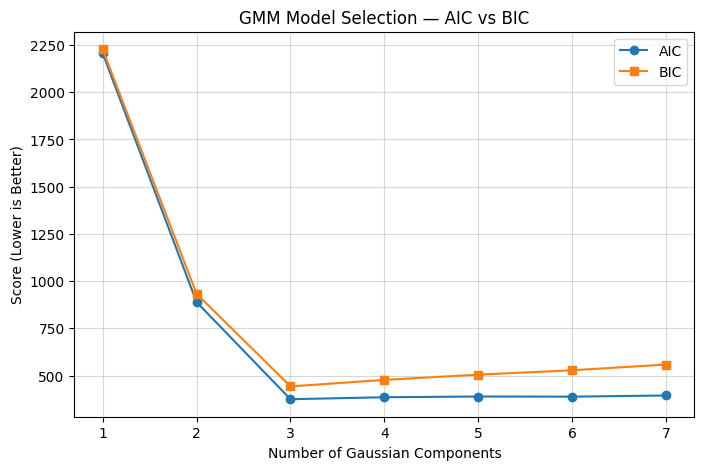

In [12]:
n_components_range = range(1, 8)
aic_scores = []
bic_scores = []

for n in n_components_range:
    m = GaussianMixture(n_components=n, random_state=42).fit(X_scaled)
    aic_scores.append(m.aic(X_scaled))
    bic_scores.append(m.bic(X_scaled))

plt.figure(figsize=(8, 5))
plt.plot(n_components_range, aic_scores, label='AIC', marker='o')
plt.plot(n_components_range, bic_scores, label='BIC', marker='s')
plt.title("GMM Model Selection — AIC vs BIC")
plt.xlabel("Number of Gaussian Components")
plt.ylabel("Score (Lower is Better)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

## 5. Optimal Component Selection & Covariance Types


In [13]:
cov_types = ['full', 'tied', 'diag', 'spherical']
for cov in cov_types:
    m = GaussianMixture(n_components=3, covariance_type=cov, random_state=42).fit(X_scaled)
    print(f"Covariance Type: {cov:<10} | Log Likelihood: {m.score(X_scaled):.4f}")

Covariance Type: full       | Log Likelihood: -0.4261
Covariance Type: tied       | Log Likelihood: -0.4302
Covariance Type: diag       | Log Likelihood: -0.4278
Covariance Type: spherical  | Log Likelihood: -0.4751
